#Eye preprocessing pipeline  

In [1]:
# Cell 1 — Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

BASE         = "/content/drive/MyDrive/EyeMotionID"
MRL_PATH     = os.path.join(BASE, "data/raw/MRL_Eye/data")
MPI_PATH     = os.path.join(BASE, "data/raw/MPIIGAZE/MPIIGaze/Data/Original")
OPENEDS_PATH = os.path.join(BASE, "data/raw/openeds/openEDS/openEDS")
PROCESSED    = os.path.join(BASE, "data/processed")
os.makedirs(PROCESSED, exist_ok=True)

IMG_SIZE = (224, 224)  # ResNet18 input size

print("✓ Drive mounted")
print("MRL exists    :", os.path.exists(MRL_PATH))
print("MPII exists   :", os.path.exists(MPI_PATH))
print("OpenEDS exists:", os.path.exists(OPENEDS_PATH))
print(f"Target size   : {IMG_SIZE[0]}x{IMG_SIZE[1]} px")

Mounted at /content/drive
✓ Drive mounted
MRL exists    : True
MPII exists   : True
OpenEDS exists: True
Target size   : 224x224 px


###Preprocessing functions

In [2]:
def preprocess_image(img_path, img_size=(224, 224)):
    """
    Load, resize and normalize a single eye image.
    Returns: numpy array of shape (224, 224, 3), normalized 0-1
    """
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    img = img.astype(np.float32) / 255.0  # normalize to 0-1
    return img

def normalize_imagenet(img):
    """
    Apply ImageNet normalization — standard for ResNet18.
    Mean: [0.485, 0.456, 0.406]
    Std:  [0.229, 0.224, 0.225]
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return (img - mean) / std

# test on one MRL image
test_img_path = None
for cls in ["awake", "sleepy"]:
    cls_path = os.path.join(MRL_PATH, "train", cls)
    files = os.listdir(cls_path)
    if files:
        test_img_path = os.path.join(cls_path, files[0])
        break

raw  = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
proc = preprocess_image(test_img_path)
norm = normalize_imagenet(proc)

print("=== Preprocessing Test ===\n")
print(f"Original shape  : {raw.shape}")
print(f"Original range  : [{raw.min()}, {raw.max()}]")
print(f"Processed shape : {proc.shape}")
print(f"Processed range : [{proc.min():.2f}, {proc.max():.2f}]")
print(f"Normalized mean : {norm.mean():.4f}")
print(f"Normalized std  : {norm.std():.4f}")
print("\n✓ Preprocessing functions ready")

=== Preprocessing Test ===

Original shape  : (68, 68, 3)
Original range  : [31, 113]
Processed shape : (224, 224, 3)
Processed range : [0.12, 0.44]
Normalized mean : -0.8651
Normalized std  : 0.2895

✓ Preprocessing functions ready


###Visualize preprocessing steps

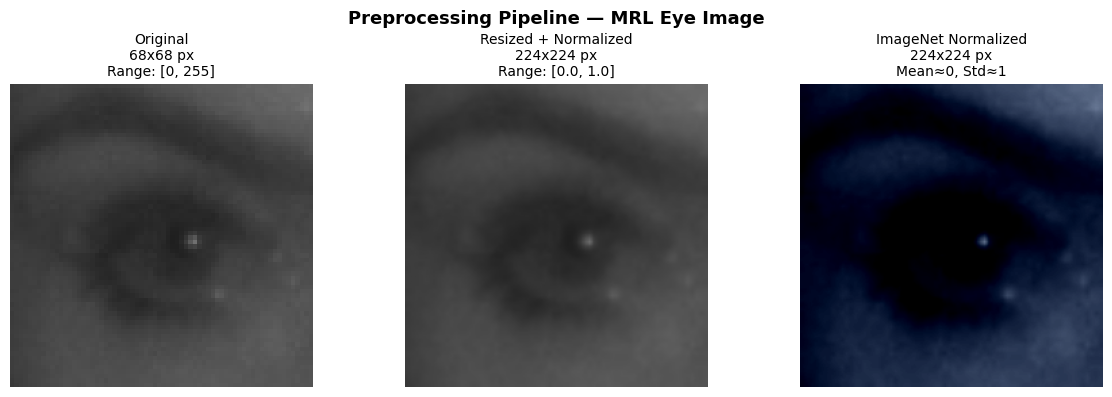

✓ Saved → results/plots/preprocessing_steps.png


In [3]:
PLOTS = os.path.join(BASE, "results/plots")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Preprocessing Pipeline — MRL Eye Image",
             fontsize=13, fontweight='bold')

# original
axes[0].imshow(raw)
axes[0].set_title(f"Original\n{raw.shape[1]}x{raw.shape[0]} px\nRange: [0, 255]", fontsize=10)
axes[0].axis("off")

# resized + normalized 0-1
axes[1].imshow(proc)
axes[1].set_title(f"Resized + Normalized\n{proc.shape[1]}x{proc.shape[0]} px\nRange: [0.0, 1.0]", fontsize=10)
axes[1].axis("off")

# imagenet normalized
norm_display = np.clip(norm * 0.5 + 0.5, 0, 1)  # scale for display
axes[2].imshow(norm_display)
axes[2].set_title(f"ImageNet Normalized\n{norm.shape[1]}x{norm.shape[0]} px\nMean≈0, Std≈1", fontsize=10)
axes[2].axis("off")

plt.tight_layout()
plt.savefig(f"{PLOTS}/preprocessing_steps.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/preprocessing_steps.png")

###Preprocess MRL Eye Dataset — sample batch

In [4]:
import os

PROCESSED_MRL = os.path.join(PROCESSED, "MRL_Eye")
os.makedirs(os.path.join(PROCESSED_MRL, "awake"),  exist_ok=True)
os.makedirs(os.path.join(PROCESSED_MRL, "sleepy"), exist_ok=True)

SAMPLE_SIZE = 500  # process 500 per class for speed
ext = {".jpg", ".jpeg", ".png", ".bmp"}

for cls in ["awake", "sleepy"]:
    cls_path  = os.path.join(MRL_PATH, "train", cls)
    out_path  = os.path.join(PROCESSED_MRL, cls)
    images    = [f for f in os.listdir(cls_path)
                 if os.path.splitext(f)[1].lower() in ext][:SAMPLE_SIZE]
    saved = 0
    for fname in images:
        proc = preprocess_image(os.path.join(cls_path, fname))
        if proc is not None:
            out_file = os.path.join(out_path, fname.replace('.bmp', '.png'))
            cv2.imwrite(out_file,
                        cv2.cvtColor((proc * 255).astype(np.uint8),
                                     cv2.COLOR_RGB2BGR))
            saved += 1
    print(f"  MRL {cls:8s} → {saved} images saved → {out_path}")

print(f"\n✓ MRL preprocessing complete")

  MRL awake    → 500 images saved → /content/drive/MyDrive/EyeMotionID/data/processed/MRL_Eye/awake
  MRL sleepy   → 500 images saved → /content/drive/MyDrive/EyeMotionID/data/processed/MRL_Eye/sleepy

✓ MRL preprocessing complete


###Preprocess MPIIGaze — sample batch

In [5]:
PROCESSED_MPI = os.path.join(PROCESSED, "MPIIGaze")
os.makedirs(PROCESSED_MPI, exist_ok=True)

participants = sorted(os.listdir(MPI_PATH))
SAMPLE_PER_PARTICIPANT = 100  # 100 images per participant

for p in participants[:5]:  # first 5 participants
    p_path  = os.path.join(MPI_PATH, p)
    out_dir = os.path.join(PROCESSED_MPI, p)
    os.makedirs(out_dir, exist_ok=True)

    # collect images from all days
    all_images = []
    for day in sorted(os.listdir(p_path)):
        day_path = os.path.join(p_path, day)
        if not os.path.isdir(day_path): continue
        for f in os.listdir(day_path):
            if f.endswith('.jpg') or f.endswith('.png'):
                all_images.append(os.path.join(day_path, f))

    # sample and preprocess
    samples = all_images[:SAMPLE_PER_PARTICIPANT]
    saved   = 0
    for img_path in samples:
        proc = preprocess_image(img_path)
        if proc is not None:
            fname    = os.path.basename(img_path)
            out_file = os.path.join(out_dir, fname)
            cv2.imwrite(out_file,
                        cv2.cvtColor((proc * 255).astype(np.uint8),
                                     cv2.COLOR_RGB2BGR))
            saved += 1

    print(f"  {p} → {saved} images saved")

print(f"\n✓ MPIIGaze preprocessing complete (first 5 participants)")

  p00 → 100 images saved
  p01 → 100 images saved
  p02 → 100 images saved
  p03 → 100 images saved
  p04 → 100 images saved

✓ MPIIGaze preprocessing complete (first 5 participants)


###Preprocess OpenEDS — sample batch

In [6]:
PROCESSED_OED = os.path.join(PROCESSED, "OpenEDS")
os.makedirs(PROCESSED_OED, exist_ok=True)

subjects = sorted([d for d in os.listdir(OPENEDS_PATH)
                   if os.path.isdir(os.path.join(OPENEDS_PATH, d))])

SAMPLE_PER_SUBJECT = 50

for s in subjects[:10]:  # first 10 subjects
    s_path  = os.path.join(OPENEDS_PATH, s)
    out_dir = os.path.join(PROCESSED_OED, s)
    os.makedirs(out_dir, exist_ok=True)

    images = sorted([f for f in os.listdir(s_path)
                     if f.endswith('.png')])[:SAMPLE_PER_SUBJECT]
    saved  = 0
    for fname in images:
        proc = preprocess_image(os.path.join(s_path, fname))
        if proc is not None:
            cv2.imwrite(os.path.join(out_dir, fname),
                        cv2.cvtColor((proc * 255).astype(np.uint8),
                                     cv2.COLOR_RGB2BGR))
            saved += 1

    print(f"  {s} → {saved} images saved")

print(f"\n✓ OpenEDS preprocessing complete (first 10 subjects)")

  S_0 → 50 images saved
  S_1 → 50 images saved
  S_10 → 50 images saved
  S_101 → 50 images saved
  S_102 → 50 images saved
  S_103 → 50 images saved
  S_104 → 50 images saved
  S_105 → 50 images saved
  S_106 → 50 images saved
  S_107 → 50 images saved

✓ OpenEDS preprocessing complete (first 10 subjects)


###Creates train/val/test splits for the preprocessed MRL dataset.

In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd

# collect all preprocessed MRL images and labels
all_paths  = []
all_labels = []

for cls, label in [("awake", 1), ("sleepy", 0)]:
    cls_path = os.path.join(PROCESSED_MRL, cls)
    for fname in os.listdir(cls_path):
        all_paths.append(os.path.join(cls_path, fname))
        all_labels.append(label)

# split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.3, random_state=42, stratify=all_labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("=== Train/Val/Test Split ===\n")
print(f"Train : {len(X_train):,} images")
print(f"Val   : {len(X_val):,} images")
print(f"Test  : {len(X_test):,} images")
print(f"Total : {len(all_paths):,} images")

# save split info to CSV
split_df = pd.DataFrame({
    "path"  : all_paths,
    "label" : all_labels,
    "split" : ["train"] * len(X_train) + ["val"] * len(X_val) + ["test"] * len(X_test)
})
csv_path = os.path.join(BASE, "data/processed/mrl_splits.csv")
split_df.to_csv(csv_path, index=False)
print(f"\n✓ Split info saved → data/processed/mrl_splits.csv")

=== Train/Val/Test Split ===

Train : 700 images
Val   : 150 images
Test  : 150 images
Total : 1,000 images

✓ Split info saved → data/processed/mrl_splits.csv


###Shows how many images were preprocessed from each dataset.

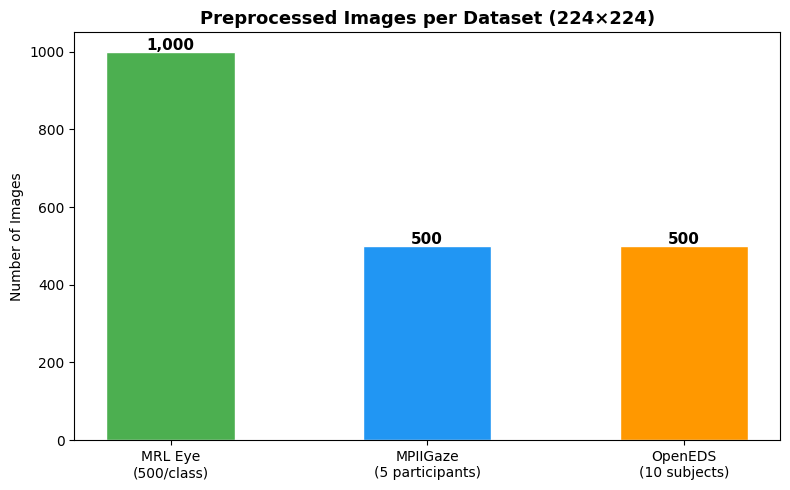

✓ Saved → results/plots/preprocessed_counts.png


In [8]:
datasets = ["MRL Eye\n(500/class)", "MPIIGaze\n(5 participants)", "OpenEDS\n(10 subjects)"]
counts   = [
    sum(len(os.listdir(os.path.join(PROCESSED_MRL, c)))
        for c in ["awake", "sleepy"]),
    sum(len(os.listdir(os.path.join(PROCESSED_MPI, p)))
        for p in os.listdir(PROCESSED_MPI)
        if os.path.isdir(os.path.join(PROCESSED_MPI, p))),
    sum(len(os.listdir(os.path.join(PROCESSED_OED, s)))
        for s in os.listdir(PROCESSED_OED)
        if os.path.isdir(os.path.join(PROCESSED_OED, s))),
]
colors = ["#4CAF50", "#2196F3", "#FF9800"]

plt.figure(figsize=(8, 5))
bars = plt.bar(datasets, counts, color=colors, edgecolor='white', width=0.5)
plt.title("Preprocessed Images per Dataset (224×224)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Images")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"{count:,}", ha="center", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS}/preprocessed_counts.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/preprocessed_counts.png")

###Summary

In [10]:
print("=" * 50)
print("   DAY 12 — DATA PREPROCESSING SUMMARY")
print("=" * 50)
print()
print("Preprocessing steps:")
print("  ✓ Resize to 224x224 px (ResNet18 input size)")
print("  ✓ Normalize to [0, 1] range")
print("  ✓ ImageNet normalization (mean/std)")
print()
print("Datasets preprocessed:")
print("  ✓ MRL Eye   — 500 images per class")
print("  ✓ MPIIGaze  — 100 images per participant (5 participants)")
print("  ✓ OpenEDS   — 50 images per subject (10 subjects)")
print()
print("Splits generated:")
print(f"  ✓ Train : {len(X_train):,} images")
print(f"  ✓ Val   : {len(X_val):,} images")
print(f"  ✓ Test  : {len(X_test):,} images")
print()
print("Files saved:")
print("  ✓ data/processed/MRL_Eye/")
print("  ✓ data/processed/MPIIGaze/")
print("  ✓ data/processed/OpenEDS/")
print("  ✓ data/processed/mrl_splits.csv")
print()
print("Plots saved → results/plots/")
print("  ✓ preprocessing_steps.png")
print("  ✓ preprocessed_counts.png")
print()
print("Week 2 deliverable complete:")
print("  ✓ Eye preprocessing pipeline")
print()
print("=" * 50)

   DAY 12 — DATA PREPROCESSING SUMMARY

Preprocessing steps:
  ✓ Resize to 224x224 px (ResNet18 input size)
  ✓ Normalize to [0, 1] range
  ✓ ImageNet normalization (mean/std)

Datasets preprocessed:
  ✓ MRL Eye   — 500 images per class
  ✓ MPIIGaze  — 100 images per participant (5 participants)
  ✓ OpenEDS   — 50 images per subject (10 subjects)

Splits generated:
  ✓ Train : 700 images
  ✓ Val   : 150 images
  ✓ Test  : 150 images

Files saved:
  ✓ data/processed/MRL_Eye/
  ✓ data/processed/MPIIGaze/
  ✓ data/processed/OpenEDS/
  ✓ data/processed/mrl_splits.csv

Plots saved → results/plots/
  ✓ preprocessing_steps.png
  ✓ preprocessed_counts.png

Week 2 deliverable complete:
  ✓ Eye preprocessing pipeline

